# Step 1 — Project Setup

Paper reproduced: *Beyond Flesch-Kincaid: Prompt-based Metrics Improve Difficulty Classification of Educational Texts* (Rooein et al., 2024).

This first step just gets the environment ready. It:
- pins the packages from Appendix B
- pulls down NLTK resources and the spaCy English model
- fixes the config constants against what the paper actually reports
- mounts Drive so the later steps can read/write a shared folder

— Shrishti

## 1.1 Install Dependencies

In [ ]:
# Package versions come straight from Appendix B. Keeping them pinned so
# textstat / nltk don't drift between runs.
!pip install -q nltk==3.8.1 pandas==2.2.0 textstat==0.7.3 spacy==3.7.4
!pip install -q scikit-learn==1.4.0 numpy==1.26.4
!pip install -q transformers==4.38.0 accelerate==0.27.0 bitsandbytes==0.42.0
!pip install -q datasets==2.17.0
!pip install -q matplotlib==3.8.3 seaborn==0.13.2


In [ ]:
# spaCy English model (small) — used in Step 3 for dependency parsing
!python -m spacy download en_core_web_sm


  ERROR: HTTP error 404 while getting https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz
ERROR: Could not install requirement https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz because of HTTP error 404 Client Error: Not Found for url: https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz for URL https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz


## 1.2 Download NLTK Data (Appendix B)

In [ ]:
# Colab's pre-installed numpy is sometimes numpy 2.x, which breaks scipy's
# binary ABI ("dtype size changed" error on import). Force-reinstalling the
# pinned pair usually clears it. If you still see that error, RESTART RUNTIME
# and re-run this cell.
!pip uninstall -y numpy scipy
!pip install numpy==1.26.4 scipy==1.12.0 -q

try:
    import nltk
except ValueError as e:
    # The dtype-size error is the one I've actually hit in Colab; everything
    # else I want to see the real traceback for.
    if "numpy.dtype size changed" in str(e):
        print("!" * 76)
        print("!" * 76)
        print("numpy/scipy ABI mismatch detected.")
        print("Colab probably has numpy 2.x pre-loaded — the in-process import cached it.")
        print("Fix: Runtime -> Restart runtime, then run this cell again.")
        print("!" * 76)
        print("!" * 76)
        raise
    else:
        raise

# Resources listed in Appendix B
nltk_resources = ['stopwords', 'cmudict', 'wordnet', 'averaged_perceptron_tagger']
for resource in nltk_resources:
    nltk.download(resource, quiet=True)
    print(f"  got: {resource}")

# punkt is needed by sent_tokenize / word_tokenize in the static-metrics step.
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("  got: punkt")
print("\nNLTK ready.")


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.12.0
Uninstalling scipy-1.12.0:
  Successfully uninstalled scipy-1.12.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
access 1.1.10.post3 requi

## 1.3 Mount Google Drive (for saving outputs across sessions)

In [ ]:
import os

# Prefer Drive so intermediate outputs survive disconnects.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/text-difficulty-classification'
    IN_COLAB = True
except ImportError:
    # Running locally — just use cwd.
    PROJECT_ROOT = '.'
    IN_COLAB = False
    print("Not in Colab, using local directory.")

for subdir in ['data', 'outputs', 'outputs/static_metrics', 'outputs/prompt_metrics',
               'outputs/baselines', 'outputs/regression', 'outputs/figures']:
    os.makedirs(os.path.join(PROJECT_ROOT, subdir), exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Running in Colab: {IN_COLAB}")


Mounted at /content/drive
Project root: /content/drive/MyDrive/text-difficulty-classification
Running in Colab: True


## 1.4 Configuration (all constants from the paper)

In [ ]:
# ------------------------------------------------------------------
# Constants from the paper (Rooein et al., 2024). Grouped by section so
# I can find them when I inevitably come back to double-check a number.
# ------------------------------------------------------------------

# Section 4.1 — K12 grades collapsed into 3 levels.
EDUCATION_LEVELS = {
    "elementary": list(range(1, 6)),   # grades 1-5
    "middle":     list(range(6, 9)),   # grades 6-8
    "high":       list(range(9, 13)),  # grades 9-12
}
LABEL_MAP = {"elementary": 0, "middle": 1, "high": 2}
LABEL_NAMES = ["elementary", "middle", "high"]

# Section 4.1 — dataset sizing
DATASET_NAME = "derek-thomas/ScienceQA"
SAMPLES_PER_LEVEL = 1516
TOTAL_BALANCED = 4548             # = 1516 * 3
TRAIN_SIZE = 3638                 # 80%
TEST_SIZE  = 910                  # 20%

# Section 4.2 — open LLMs the paper used for the prompt-based metrics
LLM_MODELS = {
    "llama2-7b":  "meta-llama/Llama-2-7b-chat-hf",
    "llama2-13b": "meta-llama/Llama-2-13b-chat-hf",
    "mistral-7b": "mistralai/Mistral-7B-Instruct-v0.2",
    "gemma-7b":   "google/gemma-7b-it",
}

# Section 4.2 + Appendix B — inference knobs
LLM_TEMPERATURE      = 0.0
LLM_MAX_NEW_TOKENS   = 256
LLM_MAX_INPUT_LENGTH = 2048

# Section 3 — how many metrics of each kind
NUM_STATIC_METRICS = 46
NUM_PROMPT_METRICS = 63

# Section 4.5 — evaluation
BOOTSTRAP_SAMPLES  = 1000
SIGNIFICANCE_LEVEL = 0.05

# Section 4.4 — the zero-shot baseline prompt (used by Step 8, not here)
ZERO_SHOT_PROMPT = (
    "Your task is to predict the education level corresponding to a given text. "
    "You are provided with three labels to choose from: "
    "1) elementary school 2) middle school 3) high school. "
    "Text: {text} Educational level: "
)

DEFAULT_INVALID_LABEL = "elementary"
RANDOM_SEED = 42

print("Configuration loaded successfully.")


Configuration loaded successfully.


## 1.5 Verify All Imports Work

In [ ]:
# Verify all critical imports
import pandas as pd
import numpy as np
import nltk
import textstat
import spacy
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, precision_recall_fscore_support
from datasets import load_dataset
import matplotlib
import seaborn

print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"nltk:         {nltk.__version__}")
print(f"textstat:     {textstat.__version__}")
print(f"spacy:        {spacy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib:   {matplotlib.__version__}")
print(f"seaborn:      {seaborn.__version__}")

# Verify spaCy model loads
nlp = spacy.load("en_core_web_sm")
print(f"\nspaCy model 'en_core_web_sm' loaded successfully.")

# Verify NLTK resources
from nltk.corpus import stopwords, wordnet
from nltk.corpus import cmudict
sw = stopwords.words('english')
cmu = cmudict.dict()
print(f"NLTK stopwords: {len(sw)} words")
print(f"NLTK CMU dict:  {len(cmu)} entries")
print(f"\nAll imports and resources verified.")

pandas:       2.2.0
numpy:        1.26.4
nltk:         3.8.1
textstat:     (0, 7, 2)
spacy:        3.7.4
scikit-learn: 1.4.0
matplotlib:   3.8.3
seaborn:      0.13.2


/usr/local/lib/python3.12/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.4). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)



spaCy model 'en_core_web_sm' loaded successfully.
NLTK stopwords: 198 words
NLTK CMU dict:  123455 entries

All imports and resources verified.


## 1.6 Quick Sanity Check — Verify ScienceQA Dataset is Accessible

In [ ]:
# Just poke the dataset builder — actual download happens in Step 2.
from datasets import load_dataset_builder

builder = load_dataset_builder("derek-thomas/ScienceQA")
print(f"Dataset: {builder.info.description[:200]}...")
print(f"Features: {list(builder.info.features.keys())}")
print(f"\nScienceQA dataset is accessible. Full loading happens in Step 2.")


Dataset: ...
Features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution']

ScienceQA dataset is accessible. Full loading happens in Step 2.


## 1.7 Save Config to Drive (so other steps can load it)

In [ ]:
import json

config_dict = {
    "EDUCATION_LEVELS": EDUCATION_LEVELS,
    "LABEL_MAP": LABEL_MAP,
    "LABEL_NAMES": LABEL_NAMES,
    "DATASET_NAME": DATASET_NAME,
    "SAMPLES_PER_LEVEL": SAMPLES_PER_LEVEL,
    "TOTAL_BALANCED": TOTAL_BALANCED,
    "TRAIN_SIZE": TRAIN_SIZE,
    "TEST_SIZE": TEST_SIZE,
    "LLM_MODELS": LLM_MODELS,
    "LLM_TEMPERATURE": LLM_TEMPERATURE,
    "LLM_MAX_NEW_TOKENS": LLM_MAX_NEW_TOKENS,
    "LLM_MAX_INPUT_LENGTH": LLM_MAX_INPUT_LENGTH,
    "NUM_STATIC_METRICS": NUM_STATIC_METRICS,
    "NUM_PROMPT_METRICS": NUM_PROMPT_METRICS,
    "BOOTSTRAP_SAMPLES": BOOTSTRAP_SAMPLES,
    "SIGNIFICANCE_LEVEL": SIGNIFICANCE_LEVEL,
    "ZERO_SHOT_PROMPT": ZERO_SHOT_PROMPT,
    "DEFAULT_INVALID_LABEL": DEFAULT_INVALID_LABEL,
    "RANDOM_SEED": RANDOM_SEED,
}

config_path = os.path.join(PROJECT_ROOT, 'outputs', 'config.json')
with open(config_path, 'w') as f:
    json.dump(config_dict, f, indent=2)

print(f"Config saved to: {config_path}")
print(f"\n--- Step 1 Complete ---")
print(f"Next: Run Step 2 (Dataset Loading & Preprocessing)")

Config saved to: /content/drive/MyDrive/text-difficulty-classification/outputs/config.json

--- Step 1 Complete ---
Next: Run Step 2 (Dataset Loading & Preprocessing)


# Step 2 — Load + prep the dataset

Paper section: **4.1**.

What happens here:
1. Pull the full ScienceQA dataset (21,208 rows across splits)
2. Keep only text-only questions (drop the image-ones)
3. Dedupe on the combined text
4. Map numeric grades to 3 buckets: elementary / middle / high
5. Sub-sample 1,516 per bucket -> 4,548 total
6. 80/20 stratified train-test split

CPU is fine. Dataset download is ~2 minutes the first time.

In [ ]:
# one-time install
!pip install -q datasets==2.17.0 pandas==2.2.0 numpy==1.26.4


In [ ]:
import os
import json
import pandas as pd
import numpy as np
from datasets import load_dataset

# paths — same layout as Step 1
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/text-difficulty-classification'
except ImportError:
    PROJECT_ROOT = '.'

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2.1 Load ScienceQA Dataset

In [ ]:
# Grab all splits and print a breakdown
dataset = load_dataset("derek-thomas/ScienceQA")

print(f"Available splits: {list(dataset.keys())}")
for split in dataset:
    print(f"  {split}: {len(dataset[split])} samples")

total = sum(len(dataset[s]) for s in dataset)
print(f"\nTotal across all splits: {total}")
print(f"Paper states: 21,208")


Generating train split:   0%|          | 0/12726 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4241 [00:00<?, ? examples/s]

Available splits: ['train', 'validation', 'test']
  train: 12726 samples
  validation: 4241 samples
  test: 4241 samples

Total across all splits: 21208
Paper states: 21,208


In [ ]:
# Flatten the splits into one big DataFrame (keep track of where each row came from)
dfs = []
for split_name in dataset:
    df_split = dataset[split_name].to_pandas()
    df_split['original_split'] = split_name
    dfs.append(df_split)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Combined DataFrame: {len(df_all)} rows")
print(f"Columns: {list(df_all.columns)}")


Combined DataFrame: 21208 rows
Columns: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution', 'original_split']


In [ ]:
# Peek at one row so I know what the schema looks like
print("Sample row:")
print(df_all.iloc[0].to_dict())


Sample row:
{'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\xee\x00\x00\x01\xad\x08\x02\x00\x00\x00\xc6[f\xc2\x00\x01\x00\x00IDATx\x9c\xec\xfdwt\\\xc9\x9e\xdf\t\xfe"\xae\xcf\x9b\xde\xc2{\x10 @\xefYd\xb1\xc8\xb2,\xfb\xaa\x9e\xed\xee\xa7UKj\xd9\xd1hgGs\xb4\xd2\xee\xce\xb6tfWs\x8eV\xe6\x8c\xb4sf{4#7jI\xef\xf5\xeb\xe7\xca\x1bV\x15\x8b\xde\x93 \x00\x12\xde\xdb\xf4>\xf3\xba\x88\xfd\x03x4 \x08\x9b\x99\x00\xc8\xfb\xf9\xa3\x8a\xb87n\xdc\xb8\x99y#\xbe\x11\xf13\x88R\n\x00\x00\x10\x8f\xc7\x93\xc9d.\x97\xd3u\x1dLLLLLLLL6\x1f,\xcbZ,\x16\xbb\xdd\xeep8\xe6\x8e J\xa9\xae\xeb\x13\x13\x13\x99Lfc\x1bgbbbbbbb\xb2BdY\xae\xaa\xaabY\x16QJGFF2\x99L$\x8f\xaf\xde\xec\x94Ym{C\xe5F7\xcf\xc4\xc4\xc4\xc4\xa4`\xdc\xea\xea\x9d\x8ed\xe5\xd6We\x7f#b\xd8\xa2\xde+\x7f\xebO\x8f\xed\xaeG\x08\x15\xf5.&\xcf3\x842\x06+\xda\x1c.;\xa3\xc8\xb2\\WW\xc7\xc6b\xb1L&\x13\xca\xe1z\x9fEk\xf4\xdd\xee\xecn\xa8?\xbe\xd1\xed41111)\x18\x08 \x9e\xd5\xe3\xc9\xe1\xe9\x9eN\xda\xf0:\'\xd9\x8bt#CSd\xab\xb5\xb1\xa1\xa1H\xf5\x9

## 2.2 Filter Out Image-based Questions

Paper (Section 4.1): *"we sample only those that do not use images in questions or explanations"*

In [ ]:
# 'image' is null for text-only items. First try the fast path.
print(f"Before filtering: {len(df_all)} samples")

df_text_only = df_all[df_all['image'].isna() | (df_all['image'] == '')].copy()

# Fallback: if the column holds raw bytes or mixed types, the simple mask above
# might miss them. Use an explicit predicate in that case.
if len(df_text_only) == 0:
    df_text_only = df_all[df_all['image'].apply(
        lambda x: x is None or x == '' or (isinstance(x, str) and x == '')
    )].copy()

print(f"After filtering (text-only): {len(df_text_only)} samples")
print(f"Removed {len(df_all) - len(df_text_only)} image-based questions")


Before filtering: 21208 samples
After filtering (text-only): 10876 samples
Removed 10332 image-based questions


## 2.3 Map Grade Levels to 3 Education Categories

Paper (Section 4.1):
- Elementary: grades 1-5
- Middle: grades 6-8  
- High: grades 9-12

In [ ]:
# quick look at the raw grade column before I map it
print("Grade distribution:")
print(df_text_only['grade'].value_counts().sort_index())


Grade distribution:
grade
grade1       87
grade10     557
grade11     539
grade12     406
grade2      985
grade3     1469
grade4     1653
grade5     1440
grade6      992
grade7     1281
grade8      976
grade9      491
Name: count, dtype: int64


In [ ]:
def map_grade_to_level(grade):
    # ScienceQA uses strings like 'grade1' / 'grade 1'; sometimes ints too.
    # Pull the digits out and bucket per Section 4.1.
    """ScienceQA grade label ('grade1'..'grade12') -> education bucket.
    Returns 'elementary' (1-5), 'middle' (6-8), or 'high' (9-12).
    """
    if isinstance(grade, (int, float)):
        g = int(grade)
    elif isinstance(grade, str):
        g = int(''.join(filter(str.isdigit, grade)))
    else:
        return None

    if 1 <= g <= 5:
        return 'elementary'
    elif 6 <= g <= 8:
        return 'middle'
    elif 9 <= g <= 12:
        return 'high'
    return None


df_text_only['education_level'] = df_text_only['grade'].apply(map_grade_to_level)

# Anything that didn't map cleanly — drop it.
df_text_only = df_text_only.dropna(subset=['education_level'])

print("Education level distribution:")
print(df_text_only['education_level'].value_counts())


Education level distribution:
education_level
elementary    5634
middle        3249
high          1993
Name: count, dtype: int64


## 2.4 Construct Full Text

Each ScienceQA entry has: question, choices, solution/lecture. We combine them into a unified text for metric computation, while also keeping components separate for static metrics that need them individually (Section 3.2).

In [ ]:
def build_full_text(row):
    # ScienceQA gives us question / choices / solution / lecture as separate
    # fields. The paper treats them as one text blob for metric computation.
    # Order matters here — don't reorder without regenerating the CSVs.
    """Glue ScienceQA's question / choices / solution / lecture together.
    Order: question -> choices -> solution -> lecture (matches paper).
    Skips empties so a missing lecture doesn't leak a leading space.
    """
    parts = []

    if pd.notna(row.get('question')) and row['question']:
        parts.append(str(row['question']))

    choices = row.get('choices', [])
    if len(choices) > 0:
        parts.append(' '.join(str(c) for c in choices))

    if pd.notna(row.get('solution')) and row['solution']:
        parts.append(str(row['solution']))

    if pd.notna(row.get('lecture')) and row['lecture']:
        parts.append(str(row['lecture']))

    return ' '.join(parts)


df_text_only['full_text'] = df_text_only.apply(build_full_text, axis=1)

# Also keep each piece on its own — Step 3 needs them for the per-component
# metrics (Section 3.2).
df_text_only['text_question'] = df_text_only['question'].fillna('')
df_text_only['text_solution'] = df_text_only['solution'].fillna('')
df_text_only['text_lecture']  = df_text_only['lecture'].fillna('')

print(f"Sample full_text (first 300 chars):")
print(df_text_only['full_text'].iloc[0][:300])
print(f"\nAvg text length: {df_text_only['full_text'].str.len().mean():.0f} chars")


Sample full_text (first 300 chars):
Which tense does the sentence use?
Mona will print her name with care. present tense future tense past tense The sentence is in future tense. You can tell because it uses will before the main verb, print. The verb tells you about something that is going to happen. Present tense verbs tell you about 

Avg text length: 1159 chars


## 2.5 Deduplicate

Paper (Section 4.1): *"We then deduplicate and sample..."*

In [ ]:
# Dedupe on the combined text. Paper says "we then deduplicate and sample".
print(f"Before dedup: {len(df_text_only)}")
df_dedup = df_text_only.drop_duplicates(subset=['full_text']).copy()
print(f"After dedup:  {len(df_dedup)}")
print(f"Removed {len(df_text_only) - len(df_dedup)} duplicates")
print(f"\nDistribution after dedup:")
print(df_dedup['education_level'].value_counts())


Before dedup: 10876
After dedup:  10876
Removed 0 duplicates

Distribution after dedup:
education_level
elementary    5634
middle        3249
high          1993
Name: count, dtype: int64


## 2.6 Balance Dataset (1,516 per level)

Paper (Section 4.1): *"sample 1,516 texts for each education level to create a balanced dataset of 4,548 texts"*

In [ ]:
SAMPLES_PER_LEVEL = 1516

# Make sure each level actually has enough rows before sampling.
for level in ['elementary', 'middle', 'high']:
    count = len(df_dedup[df_dedup['education_level'] == level])
    print(f"{level}: {count} available (need {SAMPLES_PER_LEVEL})")
    if count < SAMPLES_PER_LEVEL:
        print(f"  WARNING: Not enough samples! Will use {count} instead.")


elementary: 5634 available (need 1516)
middle: 3249 available (need 1516)
high: 1993 available (need 1516)


In [ ]:
# Downsample to an even 1,516 per level.
balanced_dfs = []
for level in ['elementary', 'middle', 'high']:
    level_df = df_dedup[df_dedup['education_level'] == level]
    n_samples = min(SAMPLES_PER_LEVEL, len(level_df))
    sampled = level_df.sample(n=n_samples, random_state=RANDOM_SEED)
    balanced_dfs.append(sampled)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
print(f"Balanced dataset: {len(df_balanced)} samples")
print(f"Paper expects: 4,548")
print(f"\nDistribution:")
print(df_balanced['education_level'].value_counts())


Balanced dataset: 4548 samples
Paper expects: 4,548

Distribution:
education_level
elementary    1516
middle        1516
high          1516
Name: count, dtype: int64


## 2.7 Train/Test Split (80/20)

Paper (Section 4.1): *"we use 3,638 (80%) for training and 910 (20%) for evaluation"*

In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 stratified split so each level is represented in both halves.
df_train, df_test = train_test_split(
    df_balanced,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df_balanced['education_level'],
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train set: {len(df_train)} (paper: 3,638)")
print(f"Test set:  {len(df_test)} (paper: 910)")
print(f"\nTrain distribution:")
print(df_train['education_level'].value_counts())
print(f"\nTest distribution:")
print(df_test['education_level'].value_counts())


Train set: 3638 (paper: 3,638)
Test set:  910 (paper: 910)

Train distribution:
education_level
high          1213
elementary    1213
middle        1212
Name: count, dtype: int64

Test distribution:
education_level
middle        304
high          303
elementary    303
Name: count, dtype: int64


## 2.8 Save Processed Dataset

In [ ]:
# Select columns to save
cols_to_save = [
    'question', 'choices', 'solution', 'lecture',
    'full_text', 'text_question', 'text_solution', 'text_lecture',
    'education_level', 'grade', 'subject', 'topic', 'category'
]

# Keep only columns that exist
cols_to_save = [c for c in cols_to_save if c in df_train.columns]

df_train[cols_to_save].to_csv(os.path.join(DATA_DIR, 'train.csv'), index=False)
df_test[cols_to_save].to_csv(os.path.join(DATA_DIR, 'test.csv'), index=False)

print(f"Saved train.csv: {len(df_train)} rows, {len(cols_to_save)} columns")
print(f"Saved test.csv:  {len(df_test)} rows, {len(cols_to_save)} columns")
print(f"Saved to: {DATA_DIR}")
print(f"\n--- Step 2 Complete ---")
print(f"Next: Run Step 3 (Static Metrics) [Person 1]")
print(f"  or: Run Step 4 (Prompt Metrics Definition) [Person 2]")

Saved train.csv: 3638 rows, 13 columns
Saved test.csv:  910 rows, 13 columns
Saved to: /content/drive/MyDrive/text-difficulty-classification/data

--- Step 2 Complete ---
Next: Run Step 3 (Static Metrics) [Person 1]
  or: Run Step 4 (Prompt Metrics Definition) [Person 2]


## 2.9 Verification Summary

In [ ]:
# Side-by-side sanity check against the paper's numbers.
bar = "=" * 60
print("=" * 60)
print("VERIFICATION: Paper vs. Our Reproduction")
print("=" * 60)
print(f"{'Metric':<35} {'Paper':>10} {'Ours':>10}")
print("-" * 60)
print(f"{'Total ScienceQA texts':<35} {'21,208':>10} {total:>10,}")
print(f"{'Balanced dataset size':<35} {'4,548':>10} {len(df_balanced):>10,}")
print(f"{'Samples per level':<35} {'1,516':>10} {SAMPLES_PER_LEVEL:>10,}")
print(f"{'Train size':<35} {'3,638':>10} {len(df_train):>10,}")
print(f"{'Test size':<35} {'910':>10} {len(df_test):>10,}")
print(f"{'Education levels':<35} {'3':>10} {df_balanced['education_level'].nunique():>10}")
print("=" * 60)


VERIFICATION: Paper vs. Our Reproduction
Metric                                   Paper       Ours
------------------------------------------------------------
Total ScienceQA texts                   21,208     21,208
Balanced dataset size                    4,548      4,548
Samples per level                        1,516      1,516
Train size                               3,638      3,638
Test size                                  910        910
Education levels                             3          3


# Step 3 — Static metrics (46 of them)

Paper section: **3.2** + Table 4 (appendix).

Runs all 46 hand-engineered readability / lexical / syntactic metrics on every train + test row.

The 46 break down like this:
- basic text-level (word counts, length, vocab)   -> 7
- POS counts (N / V / Adj / Adv)                  -> 4
- punctuation + numbers                           -> 2
- word complexity (complex / unique / content)    -> 4
- sentence-level (avg length, syllables / word)   -> 2
- syntactic (prep / noun / verb phrases)          -> 6
- voice (active vs passive, agentless)            -> 5
- negation                                        -> 2
- word-length std dev                             -> 1
- lexical semantics (polysemy / word senses)      -> 8
- WordNet depth (noun + verb roots)               -> 2
- readability formulas (FK, CL, ARI, SMOG, GF, TB)-> 7

Packages: nltk 3.8.1, pandas 2.2.0, textstat 0.7.3, spacy 3.7.4 (per Appendix B).

CPU is fine. ~15-30 min for 4,548 texts.

In [ ]:
!pip install -q nltk==3.8.1 pandas==2.2.0 textstat==0.7.3 spacy==3.7.4 scikit-learn==1.4.0 numpy==1.26.4
!python -m spacy download en_core_web_sm -q


  ERROR: HTTP error 404 while getting https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz
ERROR: Could not install requirement https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz because of HTTP error 404 Client Error: Not Found for url: https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz for URL https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz


In [ ]:
import os
import pandas as pd
import numpy as np
import nltk
import textstat
import spacy
import re
from collections import Counter

# NLTK resources needed by the metrics below
for resource in ['stopwords', 'cmudict', 'wordnet', 'averaged_perceptron_tagger',
                 'punkt', 'punkt_tab', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords, cmudict, wordnet
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag

nlp = spacy.load('en_core_web_sm')
STOP_WORDS = set(stopwords.words('english'))
CMU_DICT = cmudict.dict()

# paths
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/text-difficulty-classification'
except ImportError:
    PROJECT_ROOT = '.'

DATA_DIR   = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'static_metrics')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All imports ready.')


/usr/local/lib/python3.12/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.4). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports ready.


In [ ]:
# Load what Step 2 produced
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f"Train: {len(df_train)}, Test: {len(df_test)}")


Train: 3638, Test: 910


## 3.1 Helper Functions

In [ ]:
def count_syllables(word):
    # Use CMU if we have it; otherwise a simple vowel-cluster heuristic.
    """Syllable count for one word.
    Prefers CMU Pronouncing Dictionary (number of stress digits in
    the first pronunciation); falls back to a vowel-cluster heuristic
    with a silent-'e' correction for out-of-vocab words.
    """
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        # Stress digits in the first pronunciation == number of vowel phones.
        return len([ph for ph in CMU_DICT[word_lower][0] if ph[-1].isdigit()])

    word_lower = re.sub(r'[^a-z]', '', word_lower)
    if not word_lower:
        return 0
    count = 0
    vowels = 'aeiouy'
    prev_vowel = False
    for ch in word_lower:
        is_vowel = ch in vowels
        if is_vowel and not prev_vowel:
            count += 1
        prev_vowel = is_vowel
    # silent trailing 'e'
    if word_lower.endswith('e') and count > 1:
        count -= 1
    return max(count, 1)


def is_complex_word(word):
    # Gunning Fog's definition: 3+ syllables.
    """Gunning-Fog 'complex word' test: 3+ syllables."""
    return count_syllables(word) >= 3


def get_wordnet_pos(treebank_tag):
    # Treebank -> WordNet POS short-codes.
    """Map a Penn Treebank POS tag to the WordNet POS constant.
    Returns None for tags WordNet doesn't cover.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    if treebank_tag.startswith('N'):
        return wordnet.NOUN
    if treebank_tag.startswith('R'):
        return wordnet.ADV
    return None


def count_word_senses(word, pos=None):
    """Number of WordNet synsets for `word`, optionally filtered by POS."""
    return len(wordnet.synsets(word, pos=pos))


def avg_distance_to_root(word, pos):
    """Average hypernym min-depth across synsets of `word` at the given POS.
    Returns 0 when the word has no synsets (keeps arithmetic well-defined).
    """
    synsets = wordnet.synsets(word, pos=pos)
    if not synsets:
        return 0
    depths = [s.min_depth() for s in synsets]
    return np.mean(depths) if depths else 0


print('Helper functions defined.')


Helper functions defined.


## 3.2 Main Static Metrics Function

Implements all 46 metrics from Table 4 in the paper.

In [ ]:
# Auxiliary verbs for filtering in word sense metrics
AUXILIARY_VERBS = {
    'be', 'am', 'is', 'are', 'was', 'were', 'been', 'being',
    'have', 'has', 'had', 'having',
    'do', 'does', 'did',
    'will', 'would', 'shall', 'should',
    'may', 'might', 'must', 'can', 'could'
}


def compute_static_metrics(row):
    """
    Compute all 46 static metrics from Table 4 of the paper.

    Uses: full_text, text_question, text_solution, text_lecture
    Returns: dict with 46 metric values
    """
    text = str(row.get('full_text', ''))
    question = str(row.get('text_question', ''))
    solution = str(row.get('text_solution', ''))
    lecture = str(row.get('text_lecture', ''))

    if not text.strip():
        return {m: 0 for m in STATIC_METRIC_NAMES}

    # --- Tokenization ---
    words = word_tokenize(text)
    words_alpha = [w for w in words if w.isalpha()]
    words_lower = [w.lower() for w in words_alpha]
    sentences = sent_tokenize(text)

    # --- POS tagging ---
    tagged = pos_tag(words_alpha)

    nouns = [w for w, t in tagged if t.startswith('NN')]
    verbs = [w for w, t in tagged if t.startswith('VB')]
    adjectives = [w for w, t in tagged if t.startswith('JJ')]
    adverbs = [w for w, t in tagged if t.startswith('RB')]

    # --- spaCy parse for syntactic features ---
    doc = nlp(text)

    # --- Basic text-level metrics ---
    n_words_q = len(word_tokenize(question))
    n_words_a_solution = len(word_tokenize(solution))
    n_words_a_lecture = len(word_tokenize(lecture))
    text_length = len(text)
    word_count = len(words_alpha)

    # --- POS counts ---
    n_nouns = len(nouns)
    n_verbs = len(verbs)
    n_adjectives = len(adjectives)
    n_adverbs = len(adverbs)

    # --- Punctuation & numbers ---
    num_numbers = sum(1 for c in text if c.isdigit())
    num_commas = text.count(',')

    # --- Word complexity ---
    num_complex = sum(1 for w in words_alpha if is_complex_word(w))
    num_unique = len(set(words_lower))

    # FIX: Num_Content_Words = all content-bearing words (nouns, verbs, adj, adv)
    # regardless of stopword status. Num_Content_Words_No_Stopwords = content
    # words that are NOT stopwords. These must differ per Table 4.
    content_pos_words = set(w.lower() for w in nouns + verbs + adjectives + adverbs)
    num_content = len([w for w in words_lower if w in content_pos_words])
    content_words_no_stop = [w for w in words_lower if w not in STOP_WORDS]
    num_content_no_stop = len(content_words_no_stop)

    # --- Syllables & sentence length ---
    syllables = [count_syllables(w) for w in words_alpha]
    avg_syllables = np.mean(syllables) if syllables else 0
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    avg_sent_len = np.mean(sent_lengths) if sent_lengths else 0

    # --- Syntactic features (spaCy) ---
    # Prepositional phrases: count adpositions (POS='ADP') which head prep phrases
    num_prep_phrases = sum(1 for token in doc if token.pos_ == 'ADP')

    # Negation
    num_negated_stem = sum(1 for token in doc if token.dep_ == 'neg')
    negation_words = {'no', 'not', 'never', 'neither', 'nobody', 'nothing', 'nowhere', 'nor'}
    num_negated_lead_in = sum(1 for w in words_lower if w in negation_words)

    # Noun phrases
    noun_chunks = list(doc.noun_chunks)
    num_main_np = len(noun_chunks)
    np_lengths = [len(chunk) for chunk in noun_chunks]
    avg_np_length = np.mean(np_lengths) if np_lengths else 0

    # Verb phrases (count main verbs via spaCy)
    verb_phrases = [token for token in doc if token.pos_ == 'VERB']
    num_verb_phrases = len(verb_phrases)

    # --- Voice (active vs passive) ---
    # FIX: Count unique verb heads, not individual tokens, to avoid double-counting
    passive_verbs = set()
    active_verbs = set()

    for token in doc:
        if token.dep_ == 'nsubjpass':
            passive_verbs.add(token.head.i)
        if token.dep_ == 'nsubj' and token.head.pos_ == 'VERB':
            active_verbs.add(token.head.i)

    passive_count = len(passive_verbs)
    active_count = len(active_verbs)

    # Agentless passive: passive verb without a 'by' agent
    agentless_passive = 0
    for token in doc:
        if token.dep_ == 'nsubjpass':
            has_agent = any(child.dep_ == 'agent' for child in token.head.children)
            if not has_agent:
                agentless_passive += 1

    total_voice = active_count + passive_count
    prop_active = active_count / total_voice if total_voice > 0 else 1.0
    prop_passive = passive_count / total_voice if total_voice > 0 else 0.0
    ratio_active_passive = (active_count / passive_count) if passive_count > 0 else float(active_count)

    # FIX: Words before main verb — average across sentences
    words_before_verb_list = []
    for sent in doc.sents:
        for i, token in enumerate(sent):
            if token.pos_ == 'VERB' and token.dep_ in ('ROOT', 'ccomp', 'advcl'):
                words_before_verb_list.append(i)
                break
    words_before_verb = np.mean(words_before_verb_list) if words_before_verb_list else 0

    # --- Word length std dev ---
    word_lengths = [len(w) for w in words_alpha]
    word_len_std = np.std(word_lengths) if word_lengths else 0

    # --- Lexical semantics (WordNet) ---
    unique_words_lower = set(words_lower)
    num_polysemic = sum(1 for w in unique_words_lower if count_word_senses(w) > 1)
    total_senses = sum(count_word_senses(w) for w in unique_words_lower)

    # Word senses by POS
    unique_content_no_stop = set(content_words_no_stop)
    content_word_senses = sum(count_word_senses(w) for w in unique_content_no_stop)
    noun_senses = sum(count_word_senses(w.lower(), wordnet.NOUN) for w in set(nouns))
    verb_senses = sum(count_word_senses(w.lower(), wordnet.VERB) for w in set(verbs))

    non_aux_verbs = [w for w in verbs if w.lower() not in AUXILIARY_VERBS]
    non_aux_verb_senses = sum(count_word_senses(w.lower(), wordnet.VERB) for w in set(non_aux_verbs))

    adj_senses = sum(count_word_senses(w.lower(), wordnet.ADJ) for w in set(adjectives))
    adv_senses = sum(count_word_senses(w.lower(), wordnet.ADV) for w in set(adverbs))

    # Distance to root
    noun_depths = [avg_distance_to_root(w.lower(), wordnet.NOUN) for w in set(nouns)]
    verb_depths = [avg_distance_to_root(w.lower(), wordnet.VERB) for w in set(verbs)]
    dist_root_nouns = np.mean(noun_depths) if noun_depths else 0
    dist_root_verbs = np.mean(verb_depths) if verb_depths else 0

    # --- Readability formulas (textstat) ---
    fk_grade = textstat.flesch_kincaid_grade(text)
    fk_ease = textstat.flesch_reading_ease(text)
    cl_index = textstat.coleman_liau_index(text)
    ari = textstat.automated_readability_index(text)
    smog = textstat.smog_index(text)
    gunning = textstat.gunning_fog(text)

    # Traenkle-Bailer index
    # Original formula (Tränkle & Bailer, 1984) for German, adapted for English:
    # TB = 224.6814 - (79.8304 * ASL/100) - (12.24032 * PPW * 100)
    # where ASL = avg sentence length, PPW = proportion of prepositions
    # The paper cites this as one of the 46 static metrics without specifying
    # the exact formula variant. We use the standard two-variable version.
    prop_prep = num_prep_phrases / word_count if word_count > 0 else 0
    traenkle_bailer = (224.6814
                       - (79.8304 * (avg_sent_len / 100.0))
                       - (12.24032 * (prop_prep * 100.0))) if word_count > 0 else 0

    return {
        # Basic text-level (7)
        'n_words_q': n_words_q,
        'n_words_a_solution': n_words_a_solution,
        'n_words_a_lecture': n_words_a_lecture,
        'Text_Length': text_length,
        'Word_Count': word_count,
        # POS (4)
        'Nouns': n_nouns,
        'Verbs': n_verbs,
        'Adjectives': n_adjectives,
        'Adverbs': n_adverbs,
        # Punctuation & numbers (2)
        'Num_Numbers': num_numbers,
        'Num_Commas': num_commas,
        # Word complexity (4)
        'Num_Complex_Words': num_complex,
        'Num_Unique_Words': num_unique,
        'Num_Content_Words': num_content,
        'Num_Content_Words_No_Stopwords': num_content_no_stop,
        # Syllables & sentence (2)
        'Word_Length_Syllables': avg_syllables,
        'Avg_Sentence_Length': avg_sent_len,
        # Syntactic (6)
        'Num_Prepositional_Phrases': num_prep_phrases,
        'Num_Negated_Words_Stem': num_negated_stem,
        'Num_Negated_Words_Lead_In': num_negated_lead_in,
        'Num_Main_Noun_Phrases': num_main_np,
        'Avg_Main_NP_Length': avg_np_length,
        'Num_Verb_Phrases': num_verb_phrases,
        # Voice (5)
        'Prop_Active_Voice_Verbs': prop_active,
        'Prop_Passive_Voice_Verbs': prop_passive,
        'Ratio_Active_to_Passive_Verbs': ratio_active_passive,
        'Num_Words_Before_Main_Verb': words_before_verb,
        'Num_Agentless_Passive_Constructions': agentless_passive,
        # Word length (1)
        'Word_Length_Std_Dev': word_len_std,
        # Lexical semantics (8)
        'Num_Polysemic_Words': num_polysemic,
        'Num_Word_Senses': total_senses,
        'Num_Word_Senses_For_Content_Words': content_word_senses,
        'Num_Word_Senses_For_Nouns': noun_senses,
        'Num_Word_Senses_For_Verbs': verb_senses,
        'Num_Word_Senses_For_Non_Auxiliary_Verbs': non_aux_verb_senses,
        'Num_Word_Senses_For_Adjectives': adj_senses,
        'Num_Word_Senses_For_Adverbs': adv_senses,
        # WordNet depth (2)
        'Distance_To_Root_Nouns': dist_root_nouns,
        'Distance_To_Root_Verbs': dist_root_verbs,
        # Readability (7)
        'flesch_kincaid_grade': fk_grade,
        'flesch_kincaid_ease': fk_ease,
        'coleman_liau_index': cl_index,
        'automated_readability_index': ari,
        'smog_index': smog,
        'gunning_fog': gunning,
        'traenkle_bailer_index': traenkle_bailer,
    }


# Store the metric names for reference
STATIC_METRIC_NAMES = list(compute_static_metrics(
    {'full_text': 'test sentence', 'text_question': 'test', 'text_solution': '', 'text_lecture': ''}
).keys())

print(f"Total static metrics defined: {len(STATIC_METRIC_NAMES)}")
print(f"Paper expects: 46")
print(f"\nMetric names:")
for i, name in enumerate(STATIC_METRIC_NAMES, 1):
    print(f"  {i:2d}. {name}")

Total static metrics defined: 46
Paper expects: 46

Metric names:
   1. n_words_q
   2. n_words_a_solution
   3. n_words_a_lecture
   4. Text_Length
   5. Word_Count
   6. Nouns
   7. Verbs
   8. Adjectives
   9. Adverbs
  10. Num_Numbers
  11. Num_Commas
  12. Num_Complex_Words
  13. Num_Unique_Words
  14. Num_Content_Words
  15. Num_Content_Words_No_Stopwords
  16. Word_Length_Syllables
  17. Avg_Sentence_Length
  18. Num_Prepositional_Phrases
  19. Num_Negated_Words_Stem
  20. Num_Negated_Words_Lead_In
  21. Num_Main_Noun_Phrases
  22. Avg_Main_NP_Length
  23. Num_Verb_Phrases
  24. Prop_Active_Voice_Verbs
  25. Prop_Passive_Voice_Verbs
  26. Ratio_Active_to_Passive_Verbs
  27. Num_Words_Before_Main_Verb
  28. Num_Agentless_Passive_Constructions
  29. Word_Length_Std_Dev
  30. Num_Polysemic_Words
  31. Num_Word_Senses
  32. Num_Word_Senses_For_Content_Words
  33. Num_Word_Senses_For_Nouns
  34. Num_Word_Senses_For_Verbs
  35. Num_Word_Senses_For_Non_Auxiliary_Verbs
  36. Num_Word_Se

## 3.3 Test on a Single Sample

In [ ]:
# Try the function on a single row before unleashing it on all 4,548.
sample = df_train.iloc[0]
print(f"Text preview: {str(sample['full_text'])[:200]}...")
print(f"Education level: {sample['education_level']}")

metrics = compute_static_metrics(sample)
print(f"\nComputed {len(metrics)} metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Text preview: Which text uses the word literally in its traditional sense? The curry that the chef prepared was so spicy that Garrett literally had to drink three glasses of milk to ease the pain. The curry that th...
Education level: high

Computed 46 metrics:
  n_words_q: 11
  n_words_a_solution: 122
  n_words_a_lecture: 154
  Text_Length: 1775
  Word_Count: 299
  Nouns: 75
  Verbs: 57
  Adjectives: 29
  Adverbs: 30
  Num_Numbers: 0
  Num_Commas: 9
  Num_Complex_Words: 43
  Num_Unique_Words: 127
  Num_Content_Words: 192
  Num_Content_Words_No_Stopwords: 166
  Word_Length_Syllables: 1.6254
  Avg_Sentence_Length: 18.6667
  Num_Prepositional_Phrases: 27
  Num_Negated_Words_Stem: 1
  Num_Negated_Words_Lead_In: 1
  Num_Main_Noun_Phrases: 79
  Avg_Main_NP_Length: 1.9620
  Num_Verb_Phrases: 40
  Prop_Active_Voice_Verbs: 0.7692
  Prop_Passive_Voice_Verbs: 0.2308
  Ratio_Active_to_Passive_Verbs: 3.3333
  Num_Words_Before_Main_Verb: 6.1333
  Num_Agentless_Passive_Constructions: 6
  Word_Length

## 3.4 Compute Static Metrics for All Train & Test Data

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()


def compute_all_static_metrics(df, desc='Computing'):
    # Simple for-loop with a progress bar — df.apply was noticeably slower here
    # because of the spaCy load per row.
    """Run compute_static_metrics over every row in `df` and return a new
    DataFrame of metric columns. `label` is just used in the progress bar.
    """
    out = []
    for idx in tqdm(range(len(df)), desc=desc):
        out.append(compute_static_metrics(df.iloc[idx]))
    return pd.DataFrame(out)


print('Computing static metrics for TRAIN set...')
train_static = compute_all_static_metrics(df_train, desc='Train')

print('\nComputing static metrics for TEST set...')
test_static  = compute_all_static_metrics(df_test,  desc='Test')

print(f'\nTrain static metrics shape: {train_static.shape}')
print(f'Test static metrics shape:  {test_static.shape}')


Computing static metrics for TRAIN set...


Train:   0%|          | 0/3638 [00:00<?, ?it/s]


Computing static metrics for TEST set...


Test:   0%|          | 0/910 [00:00<?, ?it/s]


Train static metrics shape: (3638, 46)
Test static metrics shape:  (910, 46)


## 3.5 Validate Metrics

In [ ]:
print(f"Number of metrics: {train_static.shape[1]} (paper: 46)")
print(f"\nMetric statistics (train):")
print(train_static.describe().round(2).T.to_string())

# Watch for NaNs / infs — textstat can produce them on degenerate text.
nan_counts = train_static.isna().sum()
inf_counts = (train_static == np.inf).sum() + (train_static == -np.inf).sum()
if nan_counts.sum() > 0:
    print(f"\nWARNING: NaN values found:")
    print(nan_counts[nan_counts > 0])
if inf_counts.sum() > 0:
    print(f"\nWARNING: Inf values found:")
    print(inf_counts[inf_counts > 0])


Number of metrics: 46 (paper: 46)

Metric statistics (train):
                                          count     mean     std    min     25%      50%      75%      max
n_words_q                                3638.0    19.21   14.85   4.00   10.00    16.00    26.00   158.00
n_words_a_solution                       3638.0    50.68   40.65   1.00   26.00    39.00    63.00   270.00
n_words_a_lecture                        3638.0   161.30  104.87   1.00   88.00   133.00   219.00   706.00
Text_Length                              3638.0  1260.47  673.31  49.00  785.25  1037.00  1682.00  4038.00
Word_Count                               3638.0   213.18  112.38   7.00  137.00   174.00   287.00   621.00
Nouns                                    3638.0    65.16   40.33   4.00   40.00    52.00    82.00   326.00
Verbs                                    3638.0    39.51   19.53   0.00   24.00    37.00    52.00   105.00
Adjectives                               3638.0    19.69   12.48   0.00   10.00   

In [ ]:
# Zero-fill the bad values so the regression step doesn't explode.
train_static = train_static.replace([np.inf, -np.inf], 0).fillna(0)
test_static  = test_static.replace([np.inf, -np.inf], 0).fillna(0)
print('Cleaned NaN/Inf values.')


Cleaned NaN/Inf values.


## 3.6 Save Static Metrics

In [ ]:
# Save metrics with education labels
train_static['education_level'] = df_train['education_level'].values
test_static['education_level'] = df_test['education_level'].values

train_static.to_csv(os.path.join(OUTPUT_DIR, 'train_static_metrics.csv'), index=False)
test_static.to_csv(os.path.join(OUTPUT_DIR, 'test_static_metrics.csv'), index=False)

print(f"Saved train_static_metrics.csv: {train_static.shape}")
print(f"Saved test_static_metrics.csv:  {test_static.shape}")
print(f"Saved to: {OUTPUT_DIR}")
print(f"\n--- Step 3 Complete ---")
print(f"Next: Step 4 (Prompt-based Metrics Definition) [Person 2]")

Saved train_static_metrics.csv: (3638, 47)
Saved test_static_metrics.csv:  (910, 47)
Saved to: /content/drive/MyDrive/text-difficulty-classification/outputs/static_metrics

--- Step 3 Complete ---
Next: Step 4 (Prompt-based Metrics Definition) [Person 2]


## 3.7 Quick Visualization — Metric Distributions by Level

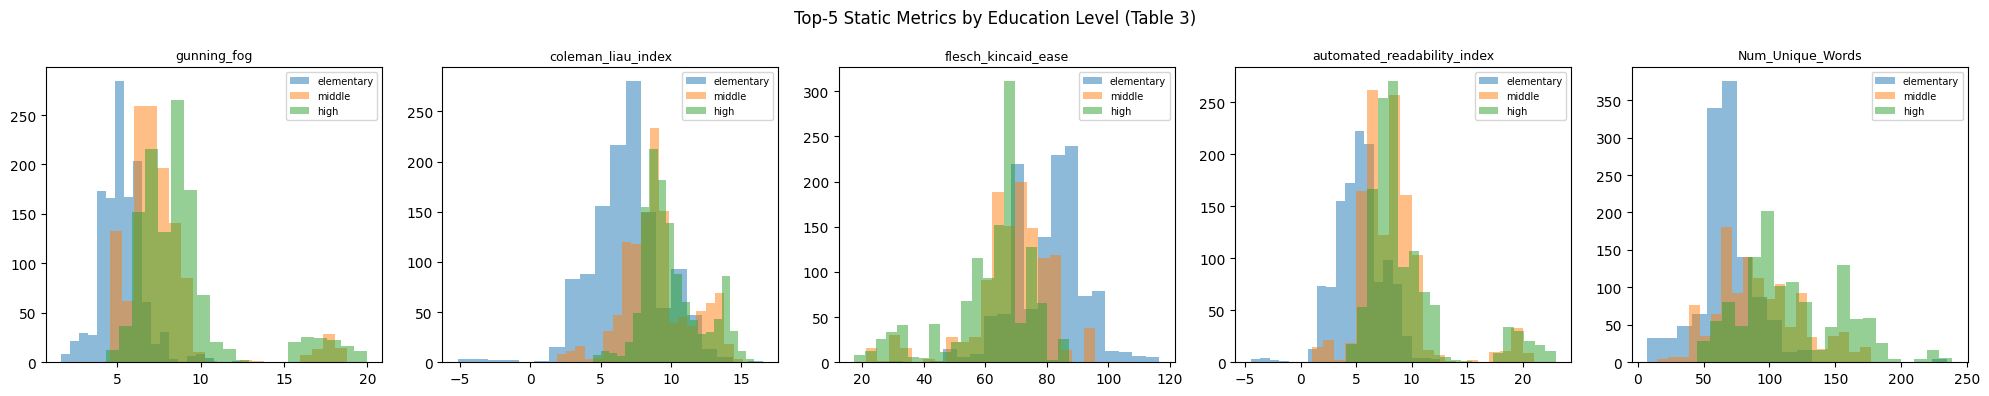

Saved distribution plot.


In [ ]:
import matplotlib.pyplot as plt

# Quick eyeball of the top-5 static metrics (from Table 3) split by level.
top_metrics = ['gunning_fog', 'coleman_liau_index', 'flesch_kincaid_ease',
               'automated_readability_index', 'Num_Unique_Words']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, metric in zip(axes, top_metrics):
    for level in ['elementary', 'middle', 'high']:
        mask = train_static['education_level'] == level
        ax.hist(train_static.loc[mask, metric], alpha=0.5, label=level, bins=20)
    ax.set_title(metric, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Top-5 static metrics by education level (Table 3)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'static_metrics_distribution.png'), dpi=150)
plt.show()
print('Saved distribution plot.')


# Step 4 — Prompt-based metric *definitions* (63 questions)

Paper section: **3.1** + Appendix C.2.

No LLM calls here — this step only builds the question list. The actual inference over all texts happens in Step 5.

Four buckets:
- **Education level** (30): 10 templates × 3 school levels
- **Lexical / syntactic complexity** (8)
- **Topic** (10)
- **Readability-based** (15): 5 indices × 3 levels

CPU-only.

In [ ]:
import os
import json

# paths
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/text-difficulty-classification'
except ImportError:
    PROJECT_ROOT = '.'

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'prompt_metrics')
os.makedirs(OUTPUT_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4.1 Education Level Metrics (30 metrics)

10 questions per level (elementary, middle, high school) = 30 total.
These are derived from the user study n-gram analysis (Section 3.1, Figure 3).

In [ ]:
# 10 question templates applied to each of 3 education levels
LEVEL_TEMPLATES = [
    "Is this text readable for a {level} student?",
    "Is this text suitable for a {level} student?",
    "Is this text easy to understand for {level} students?",
    "Is this text relevant to curriculum topics for {level} students?",
    "Is this text relevant to the knowledge and experiences of {level} students?",
    "Could an average {level} student engage with the content of this task?",
    "Could most {level} students complete this task without significant difficulty?",
    "Is this text appropriate for the skills and knowledges of {level} students?",
    "Is the length of this text suitable for {level} students?",
    "Would the vocabulary in this text be comprehensible to {level} students?",
]

LEVELS = ["elementary school", "middle school", "high school"]

education_level_metrics = []
for level in LEVELS:
    for template in LEVEL_TEMPLATES:
        question = template.format(level=level)
        education_level_metrics.append(question)

print(f"Education level metrics: {len(education_level_metrics)}")
print(f"Paper expects: 30")
for i, q in enumerate(education_level_metrics, 1):
    print(f"  {i:2d}. {q}")

Education level metrics: 30
Paper expects: 30
   1. Is this text readable for a elementary school student?
   2. Is this text suitable for a elementary school student?
   3. Is this text easy to understand for elementary school students?
   4. Is this text relevant to curriculum topics for elementary school students?
   5. Is this text relevant to the knowledge and experiences of elementary school students?
   6. Could an average elementary school student engage with the content of this task?
   7. Could most elementary school students complete this task without significant difficulty?
   8. Is this text appropriate for the skills and knowledges of elementary school students?
   9. Is the length of this text suitable for elementary school students?
  10. Would the vocabulary in this text be comprehensible to elementary school students?
  11. Is this text readable for a middle school student?
  12. Is this text suitable for a middle school student?
  13. Is this text easy to understand 

## 4.2 Lexical/Syntactic Complexity Metrics (8 metrics)

Capture complexity features like figurative language, jargon, simple vs. complex language.

In [ ]:
complexity_metrics = [
    "Does this text contain metaphors and/or figurative language?",
    "Does this text use complex language?",
    "Does this text use simple language?",
    "Does this text contain technical jargon?",
    "Does this text contain basic concepts that are easy to comprehend?",
    "Does this text cover multiple concepts?",
    "Does this text provide a very explicit explanation?",
    "Does this text contain simple examples?",
]

print(f"Complexity metrics: {len(complexity_metrics)}")
print(f"Paper expects: 8")
for i, q in enumerate(complexity_metrics, 1):
    print(f"  {i}. {q}")

Complexity metrics: 8
Paper expects: 8
  1. Does this text contain metaphors and/or figurative language?
  2. Does this text use complex language?
  3. Does this text use simple language?
  4. Does this text contain technical jargon?
  5. Does this text contain basic concepts that are easy to comprehend?
  6. Does this text cover multiple concepts?
  7. Does this text provide a very explicit explanation?
  8. Does this text contain simple examples?


## 4.3 Topic Metrics (10 metrics)

Classify the subject area of the text — captures curriculum compacting (Stamps, 2004).

In [ ]:
topic_metrics = [
    "Is this text about science?",
    "Is this text about language science?",
    "Is this text about natural science?",
    "Is this text about social science?",
    "Is this text about math?",
    "Is this text about physics?",
    "Is this text about chemistry?",
    "Is this text about earth science?",
    "Is this text about world history?",
    "Is this text about geography?",
]

print(f"Topic metrics: {len(topic_metrics)}")
print(f"Paper expects: 10")
for i, q in enumerate(topic_metrics, 1):
    print(f"  {i}. {q}")

Topic metrics: 10
Paper expects: 10
  1. Is this text about science?
  2. Is this text about language science?
  3. Is this text about natural science?
  4. Is this text about social science?
  5. Is this text about math?
  6. Is this text about physics?
  7. Is this text about chemistry?
  8. Is this text about earth science?
  9. Is this text about world history?
  10. Is this text about geography?


## 4.4 Readability-based Metrics (15 metrics)

Based on Imperial and Madabushi (2023). 5 readability indices x 3 levels.

In [ ]:
READABILITY_INDICES = [
    "Flesch-Kincaid reading-ease score",
    "Gunning Fog Index",
    "Coleman-Liau Index",
    "Automated Readability Index (ARI)",
    "SMOG Index",
]

READER_LEVELS = ["elementary school", "middle school", "high school"]

readability_metrics = []
for index_name in READABILITY_INDICES:
    for level in READER_LEVELS:
        question = f"Based on the {index_name}, is this text suitable for {level} readers?"
        readability_metrics.append(question)

print(f"Readability metrics: {len(readability_metrics)}")
print(f"Paper expects: 15")
for i, q in enumerate(readability_metrics, 1):
    print(f"  {i:2d}. {q}")

Readability metrics: 15
Paper expects: 15
   1. Based on the Flesch-Kincaid reading-ease score, is this text suitable for elementary school readers?
   2. Based on the Flesch-Kincaid reading-ease score, is this text suitable for middle school readers?
   3. Based on the Flesch-Kincaid reading-ease score, is this text suitable for high school readers?
   4. Based on the Gunning Fog Index, is this text suitable for elementary school readers?
   5. Based on the Gunning Fog Index, is this text suitable for middle school readers?
   6. Based on the Gunning Fog Index, is this text suitable for high school readers?
   7. Based on the Coleman-Liau Index, is this text suitable for elementary school readers?
   8. Based on the Coleman-Liau Index, is this text suitable for middle school readers?
   9. Based on the Coleman-Liau Index, is this text suitable for high school readers?
  10. Based on the Automated Readability Index (ARI), is this text suitable for elementary school readers?
  11. Based

## 4.5 Combine All 63 Prompt-based Metrics

In [ ]:
ALL_PROMPT_METRICS = (
    education_level_metrics +   # 30
    complexity_metrics +         # 8
    topic_metrics +              # 10
    readability_metrics          # 15
)

# Build structured list with categories
prompt_definitions = []
for i, q in enumerate(education_level_metrics):
    prompt_definitions.append({"id": i, "question": q, "category": "education_level"})
for i, q in enumerate(complexity_metrics, len(education_level_metrics)):
    prompt_definitions.append({"id": i, "question": q, "category": "complexity"})
for i, q in enumerate(topic_metrics, len(education_level_metrics) + len(complexity_metrics)):
    prompt_definitions.append({"id": i, "question": q, "category": "topic"})
for i, q in enumerate(readability_metrics, len(education_level_metrics) + len(complexity_metrics) + len(topic_metrics)):
    prompt_definitions.append({"id": i, "question": q, "category": "readability"})

print(f"Total prompt-based metrics: {len(ALL_PROMPT_METRICS)}")
print(f"Paper expects: 63")
print(f"\nBreakdown:")
print(f"  Education level: {len(education_level_metrics)}")
print(f"  Complexity:      {len(complexity_metrics)}")
print(f"  Topic:           {len(topic_metrics)}")
print(f"  Readability:     {len(readability_metrics)}")
print(f"  Total:           {len(ALL_PROMPT_METRICS)}")

assert len(ALL_PROMPT_METRICS) == 63, f"Expected 63, got {len(ALL_PROMPT_METRICS)}"

Total prompt-based metrics: 63
Paper expects: 63

Breakdown:
  Education level: 30
  Complexity:      8
  Topic:           10
  Readability:     15
  Total:           63


## 4.6 Build the LLM Prompt Template

Each prompt-based metric is a yes/no question asked about a given text.
The LLM receives: the text + the yes/no question, and should respond with yes or no.

In [ ]:
def build_prompt(text, question):
    # The exact wording here matters — Step 5 re-defines this identically.
    # If either copy changes, downstream yes/no labels will drift.
    """Assemble the LLM prompt for one metric question.
    Template (Rooein et al., 2024): role framing ('Imagine you are
    a teacher of a/an <level> school') + question + the text to
    judge, with an explicit 'Answer with Yes or No' closer.
    """
    prompt = (
        f"Read the following text and answer the question with only 'yes' or 'no'.\n\n"
        f"Text: {text}\n\n"
        f"Question: {question}\n\n"
        f"Answer:"
    )
    return prompt


def parse_yes_no(response):
    # Map a raw LLM response to {0, 1}. Prefer the first token; fall back
    # to a 'yes'/'no' anywhere search; default to 0 on ambiguity.
    """Coerce the LLM's free-text reply into True / False / None.
    Case-insensitive; looks for the first 'yes' or 'no' token.
    """
    response_lower = response.strip().lower()
    if response_lower.startswith('yes'):
        return 1
    elif response_lower.startswith('no'):
        return 0
    if 'yes' in response_lower:
        return 1
    elif 'no' in response_lower:
        return 0
    return 0


# Show what a constructed prompt looks like
sample_text = "What is the mass of a dinner fork? 70 grams or 70 kilograms"
sample_question = ALL_PROMPT_METRICS[0]
print("Sample prompt:")
print("=" * 50)
print(build_prompt(sample_text, sample_question))
print("=" * 50)

# Parser spot-checks
for test in ['Yes', 'yes, it is', 'No', 'no, this is not', 'Yes.', 'NO', 'Maybe']:
    print(f"  '{test}' -> {parse_yes_no(test)}")


Sample prompt:
Read the following text and answer the question with only 'yes' or 'no'.

Text: What is the mass of a dinner fork? 70 grams or 70 kilograms

Question: Is this text readable for a elementary school student?

Answer:
  'Yes' -> 1
  'yes, it is' -> 1
  'No' -> 0
  'no, this is not' -> 0
  'Yes.' -> 1
  'NO' -> 0
  'Maybe' -> 0


## 4.7 Save Prompt Definitions

In [ ]:
output = {
    "total_metrics": len(ALL_PROMPT_METRICS),
    "categories": {
        "education_level": len(education_level_metrics),
        "complexity": len(complexity_metrics),
        "topic": len(topic_metrics),
        "readability": len(readability_metrics),
    },
    "metrics": prompt_definitions,
}

save_path = os.path.join(OUTPUT_DIR, 'prompt_definitions.json')
with open(save_path, 'w') as f:
    json.dump(output, f, indent=2)

# Also save the flat list for easy loading in Step 5
flat_path = os.path.join(OUTPUT_DIR, 'prompt_questions.json')
with open(flat_path, 'w') as f:
    json.dump(ALL_PROMPT_METRICS, f, indent=2)

print(f"Saved prompt_definitions.json ({len(prompt_definitions)} metrics)")
print(f"Saved prompt_questions.json (flat list)")
print(f"Saved to: {OUTPUT_DIR}")
print(f"\n--- Step 4 Complete ---")
print(f"Next: Run Step 5 (LLM Inference for Prompt Metrics) [Person 1]")
print(f"  NOTE: Step 5 requires GPU runtime in Colab!")

Saved prompt_definitions.json (63 metrics)
Saved prompt_questions.json (flat list)
Saved to: /content/drive/MyDrive/text-difficulty-classification/outputs/prompt_metrics

--- Step 4 Complete ---
Next: Run Step 5 (LLM Inference for Prompt Metrics) [Person 1]
  NOTE: Step 5 requires GPU runtime in Colab!


> **Skip this notebook's Step 5 cells** — the actual inference lives in separate per-model notebooks (one per LLM) so they can run in parallel Colab sessions. The code below is kept here for reference only.

# Step 5 — LLM inference for the 63 prompt-based metrics

Paper section: **4.2** + Appendix B.

For every text in {train, test} (4,548 texts) and every one of the 63 prompt-based questions, ask an LLM yes/no and record a 0/1.

- models: Llama2-7b, Llama2-13b, Mistral-7b-Instruct-v0.2, Gemma-7b-it
- quantization: 8-bit (Appendix B)
- temperature: 0 (greedy)
- max_new_tokens: 256
- total calls per model: 63 × 4,548 = 286,524

This takes a GPU. ~2-4 hours per model on Colab T4/A100. Run one model per session by changing `CURRENT_MODEL`.

In [ ]:
# bitsandbytes is finicky on Colab — reinstall clean each session
!pip uninstall -y bitsandbytes
!pip install -q transformers==4.38.0 accelerate==0.27.0
!pip install -q bitsandbytes
!pip install -q torch datasets==2.17.0
!pip install -q --force-reinstall pandas==2.2.0 numpy==1.26.4


Found existing installation: bitsandbytes 0.42.0
Uninstalling bitsandbytes-0.42.0:
  Successfully uninstalled bitsandbytes-0.42.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 38.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 w

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm

# paths
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/text-difficulty-classification'
except ImportError:
    PROJECT_ROOT = '.'

DATA_DIR   = os.path.join(PROJECT_ROOT, 'data')
PROMPT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'prompt_metrics')
os.makedirs(PROMPT_DIR, exist_ok=True)

print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available: True
GPU: Tesla T4
Memory: 15.6 GB


## 5.1 Select Which Model to Run

**Run this notebook 4 times**, once per model. Change `CURRENT_MODEL` each time.

In [ ]:
# Pick one model per session. Restart runtime between runs to free GPU mem.
CURRENT_MODEL = 'gemma-7b'   # 'llama2-7b' | 'llama2-13b' | 'mistral-7b' | 'gemma-7b'

MODEL_IDS = {
    'llama2-7b':  'meta-llama/Llama-2-7b-chat-hf',
    'llama2-13b': 'meta-llama/Llama-2-13b-chat-hf',
    'mistral-7b': 'mistralai/Mistral-7B-Instruct-v0.2',
    'gemma-7b':   'google/gemma-7b-it',
}

model_id = MODEL_IDS[CURRENT_MODEL]
print(f"Running model: {CURRENT_MODEL}")
print(f"HuggingFace ID: {model_id}")


Running model: gemma-7b
HuggingFace ID: google/gemma-7b-it


## 5.2 Load Data and Prompt Definitions

In [ ]:
# Data + prompts
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
df_all   = pd.concat([df_train, df_test], ignore_index=True)
df_all['split'] = ['train'] * len(df_train) + ['test'] * len(df_test)

with open(os.path.join(PROMPT_DIR, 'prompt_questions.json')) as f:
    ALL_PROMPTS = json.load(f)

print(f"Total texts: {len(df_all)} (train: {len(df_train)}, test: {len(df_test)})")
print(f"Total prompts: {len(ALL_PROMPTS)}")
print(f"Total LLM calls needed: {len(df_all) * len(ALL_PROMPTS):,}")


Total texts: 4548 (train: 3638, test: 910)
Total prompts: 63
Total LLM calls needed: 286,524


In [ ]:
# HF token for the gated Llama-2 repos. Add 'HF_TOKEN' under Colab's Secrets.
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)


## 5.3 Load LLM with 8-bit Quantization

Paper (Appendix B): *"We performed 8-bit quantization... with a maximum input length of 2048 tokens and a maximum output length of 256 tokens."*

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Appendix B: 8-bit quantization, 2048 max input, 256 max output.
quantization_config = BitsAndBytesConfig(load_in_8bit=True)

print(f"Loading tokenizer for {CURRENT_MODEL}...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading model with 8-bit quantization...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map='auto',
)
model.eval()

print(f"Model loaded: {CURRENT_MODEL}")
print(f"Device: {model.device}")


Loading tokenizer for gemma-7b...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded: gemma-7b
Device: cuda:0


In [ ]:
# Verifies bitsandbytes installed its CUDA bits correctly
!python -m bitsandbytes


=================== bitsandbytes v0.49.2 ===================
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
  libc: glibc-2.35
Python: 3.12.13
PyTorch: 2.10.0+cu128
  CUDA: 12.8
  HIP: N/A
  XPU: N/A
Related packages:
  accelerate: 0.27.0
  diffusers: 0.37.1
  numpy: 1.26.4
  pip: 24.1.2
  peft: 0.18.1
  safetensors: 0.7.0
  transformers: 4.38.0
  triton: 3.6.0
  trl: not found
PyTorch settings found: CUDA_VERSION=128, Highest Compute Capability: (7, 5).
Checking that the library is importable and CUDA is callable...
SUCCESS!


## 5.4 Inference Functions

In [ ]:
def build_prompt(text, question):
    # MUST MATCH the Step-4 template exactly.
    """Same prompt builder as the shared pipeline; duplicated here so
    Part 1's Step-5 reference cell is self-contained.
    """
    return (
        f"Read the following text and answer the question with only 'yes' or 'no'.\n\n"
        f"Text: {text}\n\n"
        f"Question: {question}\n\n"
        f"Answer:"
    )


def parse_yes_no(response):
    # same logic as Step 4 — copy here so this notebook is self-contained
    """Same yes/no parser as the shared pipeline; see build_prompt above."""
    response_lower = response.strip().lower()
    if response_lower.startswith('yes'):
        return 1
    elif response_lower.startswith('no'):
        return 0
    if 'yes' in response_lower:
        return 1
    elif 'no' in response_lower:
        return 0
    return 0


@torch.no_grad()
def get_llm_response(prompt, max_new_tokens=256):
    # Greedy decode (temperature=None + do_sample=False), 2048 input cap.
    """Single-call inference wrapper used by the Step-5 reference code.
    Uses greedy decoding (do_sample=False, temperature=None) so the
    output is deterministic for a given prompt + model + seed.
    """
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=2048,
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=None,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )

    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# Sanity check before committing to a multi-hour run.
test_prompt = build_prompt(
    "What is the mass of a dinner fork? 70 grams or 70 kilograms.",
    "Is this text readable for an elementary school student?"
)
test_response = get_llm_response(test_prompt, max_new_tokens=10)
print(f"Test response: '{test_response}'")
print(f"Parsed: {parse_yes_no(test_response)}")


Test response: ' Yes/No

The text is easy to read'
Parsed: 1


## 5.5 Main loop — all texts × all prompts

Checkpoints every 100 texts. If Colab drops, re-run this cell; it'll pick up where it left off.

In [ ]:
# Resume if a prior run left a progress file behind.
progress_path = os.path.join(PROMPT_DIR, f'{CURRENT_MODEL}_progress.csv')
if os.path.exists(progress_path):
    existing  = pd.read_csv(progress_path)
    start_idx = len(existing)
    results   = existing.to_dict('records')
    print(f"Resuming from text {start_idx}/{len(df_all)}")
else:
    start_idx = 0
    results   = []
    print(f"Starting fresh: 0/{len(df_all)}")

remaining = len(df_all) - start_idx
print(f"Remaining: {len(df_all) - start_idx} texts x {len(ALL_PROMPTS)} prompts = {(len(df_all) - start_idx) * len(ALL_PROMPTS):,} calls")


Starting fresh: 0/4548
Remaining: 4548 texts x 63 prompts = 286,524 calls


In [ ]:
SAVE_EVERY = 100  # checkpoint interval (texts)

for text_idx in tqdm(range(start_idx, len(df_all)), desc=f'{CURRENT_MODEL} inference'):
    row  = df_all.iloc[text_idx]
    text = str(row['full_text'])

    row_results = {'text_idx': text_idx, 'split': row['split']}

    for prompt_idx, question in enumerate(ALL_PROMPTS):
        prompt   = build_prompt(text, question)
        response = get_llm_response(prompt, max_new_tokens=256)   # paper spec
        row_results[f'prompt_{prompt_idx}'] = parse_yes_no(response)

    results.append(row_results)

    if (text_idx + 1) % SAVE_EVERY == 0:
        pd.DataFrame(results).to_csv(progress_path, index=False)
        print(f"  Checkpoint saved at text {text_idx + 1}/{len(df_all)}")

# final dump
df_prompt_results = pd.DataFrame(results)
df_prompt_results.to_csv(progress_path, index=False)
print(f"\nDone! {len(df_prompt_results)} texts processed.")

gemma-7b inference:   0%|          | 0/4548 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5.6 Split into Train/Test and Save Final Outputs

In [ ]:
# Split results back into train/test and save final CSVs.
prompt_cols  = [c for c in df_prompt_results.columns if c.startswith('prompt_')]
col_rename   = {f'prompt_{i}': ALL_PROMPTS[i][:80] for i in range(len(ALL_PROMPTS))}

train_mask = df_prompt_results['split'] == 'train'
test_mask  = df_prompt_results['split'] == 'test'

train_prompts = df_prompt_results.loc[train_mask, prompt_cols].reset_index(drop=True)
test_prompts  = df_prompt_results.loc[test_mask,  prompt_cols].reset_index(drop=True)

# re-attach labels
train_prompts['education_level'] = df_train['education_level'].values
test_prompts['education_level']  = df_test['education_level'].values

train_path = os.path.join(PROMPT_DIR, f'train_prompt_metrics_{CURRENT_MODEL}.csv')
test_path  = os.path.join(PROMPT_DIR, f'test_prompt_metrics_{CURRENT_MODEL}.csv')

train_prompts.to_csv(train_path, index=False)
test_prompts.to_csv(test_path,   index=False)

print(f"Train prompt metrics: {train_prompts.shape}")
print(f"Test prompt metrics:  {test_prompts.shape}")
print(f"\nSaved:")
print(f"  {train_path}")
print(f"  {test_path}")


## 5.7 Verification

In [ ]:
# Check the distribution of yes/no responses
print(f"=== {CURRENT_MODEL} Response Summary ===")
print(f"\nTrain set ({len(train_prompts)} texts):")
yes_rates_train = train_prompts[prompt_cols].mean()
print(f"  Avg 'yes' rate across all prompts: {yes_rates_train.mean():.3f}")
print(f"  Min 'yes' rate: {yes_rates_train.min():.3f}")
print(f"  Max 'yes' rate: {yes_rates_train.max():.3f}")

print(f"\nTest set ({len(test_prompts)} texts):")
yes_rates_test = test_prompts[prompt_cols].mean()
print(f"  Avg 'yes' rate across all prompts: {yes_rates_test.mean():.3f}")

print(f"\n--- Step 5 Complete for {CURRENT_MODEL} ---")
print(f"\nTo run next model:")
print(f"  1. Restart runtime (to free GPU memory)")
print(f"  2. Change CURRENT_MODEL in cell 5.1")
print(f"  3. Re-run this notebook")
print(f"\nOnce all 4 models are done:")
print(f"  -> Hand off to Person 2 for Steps 6-10")

## 5.8 (Optional) Check Which Models Are Done

In [ ]:
print("Model completion status:")
for model_name in MODEL_IDS:
    train_file = os.path.join(PROMPT_DIR, f'train_prompt_metrics_{model_name}.csv')
    test_file  = os.path.join(PROMPT_DIR, f'test_prompt_metrics_{model_name}.csv')
    if os.path.exists(train_file) and os.path.exists(test_file):
        df_check = pd.read_csv(train_file)
        print(f"  {model_name}: DONE ({df_check.shape})")
    elif os.path.exists(os.path.join(PROMPT_DIR, f'{model_name}_progress.csv')):
        df_check = pd.read_csv(os.path.join(PROMPT_DIR, f'{model_name}_progress.csv'))
        print(f"  {model_name}: IN PROGRESS ({len(df_check)}/{len(df_all)} texts)")
    else:
        print(f"  {model_name}: NOT STARTED")

print(f"\nAll files in {PROMPT_DIR}:")
for f in sorted(os.listdir(PROMPT_DIR)):
    size = os.path.getsize(os.path.join(PROMPT_DIR, f)) / 1024
    print(f"  {f} ({size:.1f} KB)")
